# From Secant to Tangent: the Derivative

**This notebook is self-contained; it recaps limits briefly before using them.**

Everyone knows how to find the slope of a straight line: rise over run. But what is the slope of a
*curve* — at one single point, where there is no run to divide by? The answer is the central
construction of calculus. Take a line through **two** points on the curve, where the slope is easy,
and then slide the second point in toward the first and watch what the slope approaches. That limit is
the **derivative**.

## Learning objectives

- Compute the slope of a **secant** line through two points on a curve.
- Watch the secant slope converge as the gap $h$ shrinks, and identify the limit as the **tangent** slope.
- Write the **difference quotient** and read it as "rise over run, in the limit."

## Background

For a function $x(t)$, the **secant** line through the points at $t_0$ and $t_0 + h$ has the ordinary
rise-over-run slope

$$\text{secant slope} = \frac{x(t_0 + h) - x(t_0)}{h}$$

This expression is the **difference quotient**. As $h \to 0$ the two points merge, and the secant
line settles onto the **tangent** — the line that just grazes the curve at $t_0$. Its slope is the
**derivative**:

$$x'(t_0) = \lim_{h \to 0} \frac{x(t_0 + h) - x(t_0)}{h}$$

Note that at $h = 0$ the fraction is literally $\frac{0}{0}$ — undefined. This is exactly the
situation from §3.2: the expression has no value at the point of interest but a perfectly good limit
approaching it. That is why derivatives need limits.

## This notebook covers

1. One secant line, and its slope.
2. A family of secants as $h$ shrinks.
3. The slope converging numerically.
4. The tangent line, drawn.

**Prerequisites:** `U3-2_Limits-1_ApproachingALimit`

**Dataset:** none — the function is entered directly (think of it as position over time).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

# shared display helper (msds520_helpers.py lives at the MSDS 520 course root).
# notebooks sit two folders below it, so '../..' points back to it.
import sys
sys.path.append('../..')
import msds520_helpers as helpers
# plotting helper: draw x-y graphs like the usual coordinate plane
def center_axes(ax):
    ax.spines['left'].set_position('zero')     # y-axis through x = 0
    ax.spines['bottom'].set_position('zero')   # x-axis through y = 0
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

## 1. One secant line

Take a position function $x(t) = \sqrt{t} + \tfrac{1}{2}\sin(2t)$ — think of an object moving along a
line, not at constant speed. Pick a time $t_0 = 1.5$ and a gap $h = 1.0$. The secant line through the
two points has a slope you can compute with nothing but arithmetic.

Physically, that slope is the **average velocity** over the interval: total distance travelled divided
by time taken.

In [2]:
def x(t):
    return np.sqrt(t) + 0.5 * np.sin(2 * t)

t0 = 1.5
h = 1.0

y0, y1 = x(t0), x(t0 + h)
slope = (y1 - y0) / h
print(f"x({t0})       = {y0:.6f}")
print(f"x({t0 + h})       = {y1:.6f}")
print(f"secant slope = ({y1:.6f} - {y0:.6f}) / {h} = {slope:.6f}")

x(1.5)       = 1.295305
x(2.5)       = 1.101677
secant slope = (1.101677 - 1.295305) / 1.0 = -0.193628


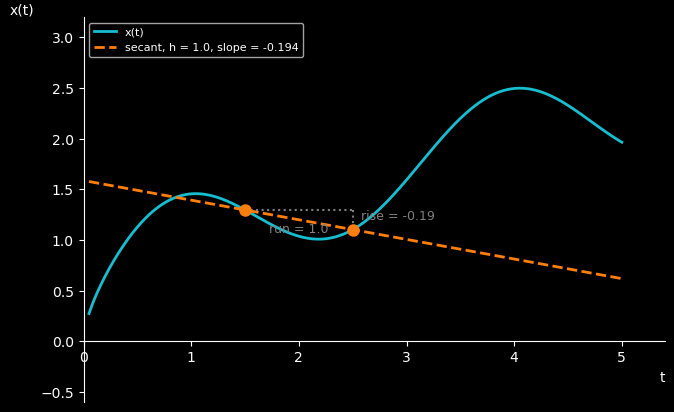

In [3]:
ts = np.linspace(0.05, 5, 400)

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.plot(ts, x(ts), color="tab:cyan", lw=2, label="x(t)")
ax.plot(ts, y0 + slope * (ts - t0), "--", color="tab:orange", lw=2,
        label=f"secant, h = {h}, slope = {slope:.3f}")
ax.plot([t0, t0 + h], [y0, y1], "o", color="tab:orange", markersize=8, zorder=5)
# the rise-over-run triangle
ax.plot([t0, t0 + h], [y0, y0], ":", color="gray")
ax.plot([t0 + h, t0 + h], [y0, y1], ":", color="gray")
ax.text(t0 + h/2, y0 - 0.22, f"run = {h}", color="gray", ha="center", fontsize=9)
ax.text(t0 + h + 0.08, (y0 + y1)/2, f"rise = {y1-y0:.2f}", color="gray", fontsize=9)

center_axes(ax)
ax.set_xlabel("t", loc="right")
ax.set_ylabel("x(t)", loc="top", rotation=0)
ax.set_xlim(0, 5.4); ax.set_ylim(-0.6, 3.2)
ax.legend(loc="upper left", fontsize=8)
plt.show()

## 2. Shrinking the gap

That secant is a crude stand-in for the slope *at* $t_0$ — it averages over a whole unit of time. So
shrink $h$ and watch. Each panel below uses a smaller gap, and the secant line tilts toward the
curve's actual direction at $t_0$.

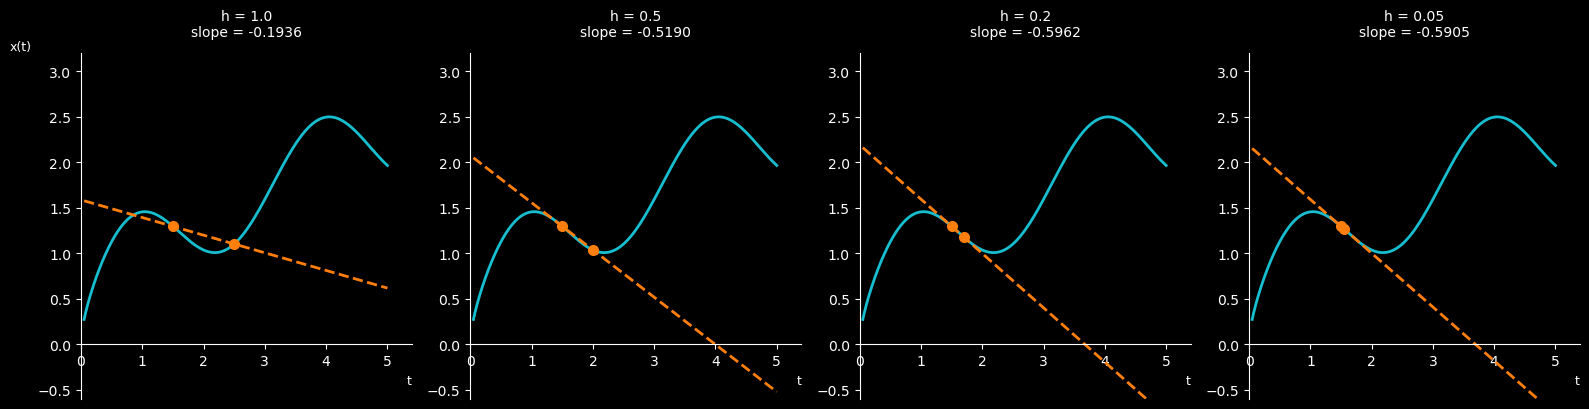

In [4]:
gaps = [1.0, 0.5, 0.2, 0.05]

fig, axes = plt.subplots(1, 4, figsize=(16, 4.2))
for ax, hh in zip(axes, gaps):
    s = (x(t0 + hh) - x(t0)) / hh
    ax.plot(ts, x(ts), color="tab:cyan", lw=2)
    ax.plot(ts, x(t0) + s * (ts - t0), "--", color="tab:orange", lw=2)
    ax.plot([t0, t0 + hh], [x(t0), x(t0 + hh)], "o", color="tab:orange", markersize=7, zorder=5)
    center_axes(ax)
    ax.set_xlim(0, 5.4); ax.set_ylim(-0.6, 3.2)
    ax.set_xlabel("t", loc="right", fontsize=9)
    ax.set_title(f"h = {hh}\nslope = {s:.4f}", pad=12, fontsize=10)
axes[0].set_ylabel("x(t)", loc="top", rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

## 3. The slope converges

The panels suggest the slope is settling down. Put numbers on it: compute the difference quotient for
a sequence of shrinking $h$ and watch the digits stop changing.

In [5]:
print(f"{'h':>10} {'difference quotient':>22} {'change from previous':>22}")
print("-" * 58)
prev = None
for hh in [1.0, 0.5, 0.1, 0.01, 1e-3, 1e-4, 1e-5, 1e-6]:
    s = (x(t0 + hh) - x(t0)) / hh
    delta = "" if prev is None else f"{abs(s - prev):22.9f}"
    print(f"{hh:10.0e} {s:22.9f} {delta:>22}")
    prev = s
print("-" * 58)

# the true derivative, by hand:  d/dt [ sqrt(t) + 0.5 sin(2t) ] = 1/(2 sqrt(t)) + cos(2t)
true_slope = 1 / (2 * np.sqrt(t0)) + np.cos(2 * t0)
print(f"{'exact':>10} {true_slope:22.9f}   <- computed with the rules from the next notebook")

         h    difference quotient   change from previous
----------------------------------------------------------
     1e+00           -0.193628183                       
     5e-01           -0.518985121            0.325356939
     1e-01           -0.595808831            0.076823709
     1e-02           -0.583767516            0.012041315
     1e-03           -0.581952685            0.001814831
     1e-04           -0.581765115            0.000187569
     1e-05           -0.581746298            0.000018818
     1e-06           -0.581744415            0.000001883
----------------------------------------------------------
     exact           -0.581744206   <- computed with the rules from the next notebook


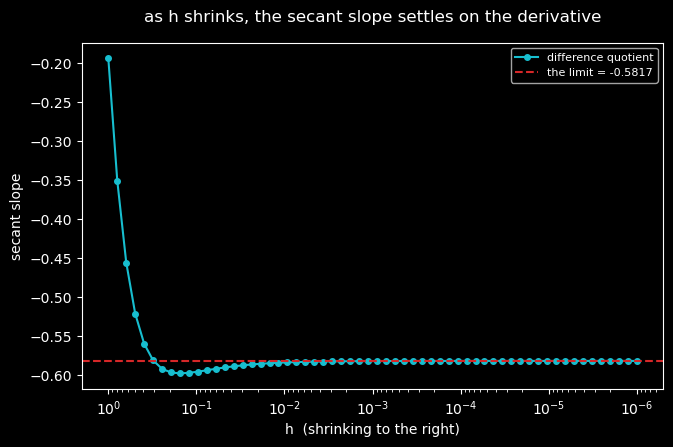

In [6]:
# the same convergence, as a picture
hs = np.logspace(0, -6, 60)
slopes = [(x(t0 + hh) - x(t0)) / hh for hh in hs]

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.semilogx(hs, slopes, "o-", color="tab:cyan", markersize=4, label="difference quotient")
ax.axhline(true_slope, color="tab:red", ls="--", label=f"the limit = {true_slope:.4f}")
ax.invert_xaxis()
ax.set_xlabel("h  (shrinking to the right)")
ax.set_ylabel("secant slope")
ax.set_title("as h shrinks, the secant slope settles on the derivative", pad=15)
ax.legend(fontsize=8)
plt.show()

## 4. The tangent line

The limit is the slope of the **tangent** — the line touching the curve at $t_0$ and heading in
exactly the direction the curve is heading. Below, the shrinking secants are drawn faintly and the
tangent is drawn solid, so you can see what they were converging to.

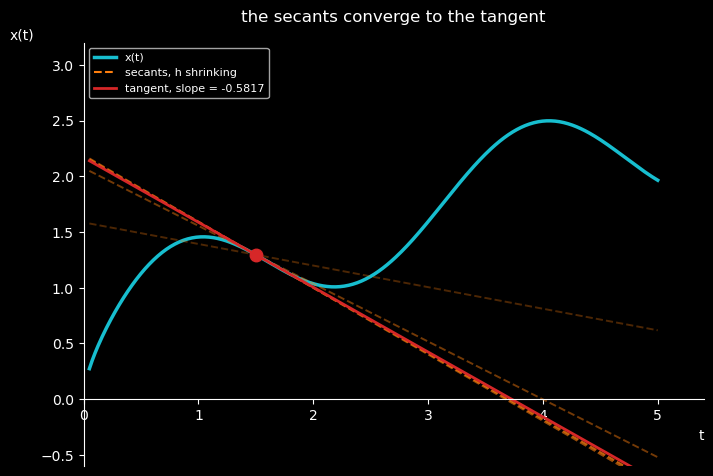

In [7]:
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.plot(ts, x(ts), color="tab:cyan", lw=2.5, label="x(t)")

for hh, alpha in zip([1.0, 0.5, 0.2, 0.05], [0.30, 0.45, 0.6, 0.75]):
    s = (x(t0 + hh) - x(t0)) / hh
    ax.plot(ts, x(t0) + s * (ts - t0), "--", color="tab:orange", lw=1.4, alpha=alpha)
ax.plot([], [], "--", color="tab:orange", label="secants, h shrinking")

ax.plot(ts, x(t0) + true_slope * (ts - t0), color="tab:red", lw=2,
        label=f"tangent, slope = {true_slope:.4f}")
ax.plot(t0, x(t0), "o", color="tab:red", markersize=9, zorder=5)

center_axes(ax)
ax.set_xlabel("t", loc="right")
ax.set_ylabel("x(t)", loc="top", rotation=0)
ax.set_xlim(0, 5.4); ax.set_ylim(-0.6, 3.2)
ax.legend(loc="upper left", fontsize=8)
ax.set_title("the secants converge to the tangent", pad=15)
plt.show()

Read physically: the secant slopes were **average** velocities over shrinking intervals, and the
tangent slope is the **instantaneous** velocity at $t_0$ — the number a speedometer shows. Averaging
over ever-shorter intervals until the interval vanishes is exactly what the limit does.

## 5. Summary

- The **secant** through two points on a curve has an ordinary rise-over-run slope, the **difference
  quotient** $\dfrac{x(t_0+h) - x(t_0)}{h}$.
- Shrinking $h$ makes the secant tilt toward the **tangent**; the limiting slope is the **derivative**
  $x'(t_0)$.
- At $h = 0$ the quotient is $0/0$ and undefined — which is precisely why the definition needs a limit.
- Average rate of change over an interval → **instantaneous** rate of change at a point.

Next: computing derivatives without doing a limit every time — the **rules**
(`U3-3_Derivatives-2_Rules`).